# MIL-based span localization for inappropriateness

This notebook evaluates Multiple Instance Learning (MIL) as a weakly supervised span localization approach.

Unlike post-hoc methods such as Integrated Gradients or SHAP, MIL trains a new model. Each argument is treated as a bag and automatically generated candidate spans are treated as latent instances. The model assigns a score to each candidate span and aggregates the strongest span scores into an argument-level prediction.

To make the results comparable to post-hoc attribution methods, the selected MIL spans are evaluated with the same perturbation protocol:

1. Select top-ranked MIL spans.
2. Mask the selected spans in the original argument.
3. Run the Ziegenbein document-level classifier on the masked text.
4. Measure the probability drop for the inappropriate class.

Hyperparameters are selected on the validation split and the final configuration is then applied to train, validation, and test.

In [ ]:
import sys
import os
import re
import gc
import json
import math
import time
import html
import random
import unicodedata
from pathlib import Path
from datetime import datetime
from itertools import product

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn

from datasets import load_dataset
from torch.utils.data import Dataset, DataLoader
from transformers import (
    AutoTokenizer,
    AutoModel,
    pipeline,
    get_linear_schedule_with_warmup,
)
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
)

CURRENT_DIR = Path.cwd()

if (CURRENT_DIR / "src").is_dir():
    PROJECT_ROOT = CURRENT_DIR
elif (CURRENT_DIR.parent / "src").is_dir():
    PROJECT_ROOT = CURRENT_DIR.parent
else:
    raise FileNotFoundError(
        "Could not locate the project root containing the 'src' directory."
    )

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from tqdm.auto import tqdm
from IPython.display import HTML, display

from src.data import load_prepared_splits
from src.utils import (
    highlight_spans,
    mask_spans_in_text,
    predict_with_pipeline,
    trim_char_span,
)

/opt/conda/lib/python3.11/site-packages/pandas/core/computation/expressions.py:23: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.10.1' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED


/opt/conda/lib/python3.11/site-packages/transformers/data/metrics/__init__.py:19: UserWarning: A NumPy version >=1.23.5 and <2.3.0 is required for this version of SciPy (detected version 2.4.6)
  from scipy.stats import pearsonr, spearmanr


In [ ]:
# Reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

# Dataset and model
DATASET_NAME = "timonziegenbein/appropriateness-corpus"
MODEL_NAME = "timonziegenbein/appropriateness-classifier-binary"

# Columns
TEXT_COL = "post_text"
TEXT_NORM_COL = "text_norm"
LABEL_COL = "Inappropriateness"
ID_COL = "post_id"

# Classifier labels
APPROPRIATE_LABEL = "LABEL_0"
INAPPROPRIATE_LABEL = "LABEL_1"

# Device settings
DEVICE = 0 if torch.cuda.is_available() else -1
TORCH_DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# General inference settings
CLASSIFIER_MAX_LENGTH = 512
CLASSIFIER_BATCH_SIZE = 32
BATCH_SIZE = 16

# MIL input settings
MIL_MAX_LENGTH = 96
MIL_BATCH_SIZE = 2
ENCODER_CHUNK_SIZE = 4
ENCODER_DTYPE = torch.bfloat16

# Training settings
NUM_EPOCHS = 3
WARMUP_RATIO = 0.1
WEIGHT_DECAY = 0.01
GRAD_CLIP_NORM = 1.0

# Separate learning rates for encoder and new MIL head
ENCODER_LR = 5e-6
HEAD_LR = 1e-4
HEAD_LR_FROZEN_ENCODER = 1e-3

# Candidate span settings
MIN_WORDS = 2
MAX_CANDIDATES = 80

# MIL initialization
INITIAL_INSTANCE_PROB = 0.02

# Perturbation settings
MASKING_TOP_N_SPANS = 3
ABLATION_MODE = "mask"

# Validation grid.
# Keep this small at first. Expand only after the pipeline works.
POOLING_MODES = [
    "topk_noisy_or",
    "topk_mean",
    "max",
]

TOP_K_VALUES = [
    1,
    3,
    5,
]

SPAN_LENGTH_SETS = [
    (3, 5, 8),
    (5, 10, 15),
    (10, 15, 20),
]

STRIDE_VALUES = [
    2,
    4,
]

FREEZE_ENCODER_VALUES = [
    True,
    # False,  # Activate only after frozen runs look reasonable.
]

# Optional debug limits. Set to None for full runs.
DEBUG_MAX_TRAIN_BAGS = None
DEBUG_MAX_VAL_BAGS = None

print("Device:", TORCH_DEVICE)

Device: cuda


In [ ]:
RUN_NAME = "mil_span_run_span_groups"
BASE_DIR = PROJECT_ROOT / "results"
OUTPUT_DIR = BASE_DIR / "mil_results" / RUN_NAME
BASE_DIR.mkdir(parents=True, exist_ok=True)
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print("Saving results to:", OUTPUT_DIR)

# Load prepared data

In [ ]:
df_all, train_df, val_df, test_df = load_prepared_splits()

print("All:", df_all.shape)
print("Train:", train_df.shape)
print("Validation:", val_df.shape)
print("Test:", test_df.shape)


print("Train confusion types:")
display(train_df["confusion_type"].value_counts())

print("Validation confusion types:")
display(val_df["confusion_type"].value_counts())

print("Test confusion types:")
display(test_df["confusion_type"].value_counts())

Train: (1533, 21)
Validation: (220, 21)
Test: (438, 21)
train


Inappropriateness
0    0.456621
1    0.543379
Name: proportion, dtype: float64

validation


Inappropriateness
0    0.436364
1    0.563636
Name: proportion, dtype: float64

test


Inappropriateness
0    0.486301
1    0.513699
Name: proportion, dtype: float64

In [7]:
pipe = pipeline(
    "text-classification",
    model=MODEL_NAME,
    device=DEVICE,
    top_k=None,
    truncation=True,
    max_length=CLASSIFIER_MAX_LENGTH,
)

classifier_tokenizer = pipe.tokenizer
classifier_model = pipe.model
classifier_model.eval()

MASK_TOKEN = (
    classifier_tokenizer.mask_token
    if classifier_tokenizer.mask_token is not None
    else "[MASK]"
)

print("MASK_TOKEN:", MASK_TOKEN)
print("label2id:", classifier_model.config.label2id)
print("id2label:", classifier_model.config.id2label)

MASK_TOKEN: [MASK]
label2id: {'LABEL_0': 0, 'LABEL_1': 1}
id2label: {0: 'LABEL_0', 1: 'LABEL_1'}


## Candidate span generation

MIL needs candidate spans before training.  
Each argument is treated as a bag and the generated spans are treated as latent instances.

The parameter `span_lengths` controls the word-window lengths used to generate candidate spans.  

The parameter `stride` controls how densely candidate spans are generated.

In [ ]:
def whitespace_token_offsets(text):
    """
    Return whitespace-based tokens with character offsets.
    
    This is intentionally simple and stable for character-level span extraction.
    """
    return [
        {
            "word_index": i,
            "text": match.group(),
            "char_start": int(match.start()),
            "char_end": int(match.end()),
        }
        for i, match in enumerate(re.finditer(r"\S+", str(text)))
    ]


def evenly_limit_candidates(candidates, max_candidates):
    """
    Limit candidates while preserving coverage across the full argument.
    
    This avoids keeping only early spans, which would bias localization toward
    the beginning of the argument.
    """
    if max_candidates is None or len(candidates) <= max_candidates:
        return candidates
    
    indices = np.linspace(0, len(candidates) - 1, max_candidates).round().astype(int)
    indices = sorted(set(indices.tolist()))
    return [candidates[i] for i in indices]


def make_candidate_spans(
    text,
    span_lengths=(5, 10, 15),
    stride=4,
    min_words=MIN_WORDS,
    max_candidates=MAX_CANDIDATES,
):
    """
    Create multi-length candidate spans for MIL.
    
    Each candidate span stores:
    - character offsets,
    - whitespace-word offsets,
    - candidate length,
    - text span.
    """
    text = str(text)
    words = whitespace_token_offsets(text)
    
    if len(words) == 0:
        return []
    
    spans = []
    seen = set()
    
    for span_length in span_lengths:
        for word_start_idx in range(0, len(words), stride):
            word_end_exclusive = min(word_start_idx + span_length, len(words))
            window = words[word_start_idx:word_end_exclusive]
            
            if len(window) < min_words:
                continue
            
            char_start = window[0]["char_start"]
            char_end = window[-1]["char_end"]
            char_start, char_end = trim_char_span(text, char_start, char_end)
            
            if char_end <= char_start:
                continue
            
            key = (char_start, char_end)
            if key in seen:
                continue
            
            seen.add(key)
            
            spans.append({
                "span_text": text[char_start:char_end],
                "char_start": int(char_start),
                "char_end": int(char_end),
                "word_start_idx": int(word_start_idx),
                "word_end_idx": int(word_end_exclusive - 1),
                "span_len_words": int(word_end_exclusive - word_start_idx),
                "span_len_chars": int(char_end - char_start),
                "candidate_span_length": int(span_length),
            })
            
            if word_end_exclusive == len(words):
                break
    
    spans = evenly_limit_candidates(spans, max_candidates=max_candidates)
    return spans


example = train_df.iloc[0]
example_spans = make_candidate_spans(
    example[TEXT_NORM_COL],
    span_lengths=(5, 10, 15),
    stride=4,
)

print("Example text:", example[TEXT_NORM_COL])
print("Number of spans:", len(example_spans))
display(pd.DataFrame(example_spans).head())

Example text: people cant be forced to wear school uniforms, i mean each person has theri own wish whether they want to or dont want to wear school uniforms. I think each principal should think once again regarding the uniforms
Number of spans: 25


,span_text,char_start,char_end,word_start_idx,word_end_idx,span_len_words,span_len_chars,candidate_span_length
0,people cant be forced to,0,24,0,4,5,24,5
1,"to wear school uniforms, i",22,48,4,8,5,26,5
2,i mean each person has,47,69,8,12,5,22,5
3,has theri own wish whether,66,92,12,16,5,26,5
4,whether they want to or,85,108,16,20,5,23,5


In [10]:
class AppropriatenessMILDataset(Dataset):
    """
    Dataset for MIL span localization.
    
    One item corresponds to one argument-level bag.
    Candidate spans are latent instances within the bag.
    """
    def __init__(
        self,
        df,
        span_lengths=(5, 10, 15),
        stride=4,
        label_col=LABEL_COL,
        text_col=TEXT_NORM_COL,
        max_candidates=MAX_CANDIDATES,
    ):
        self.rows = []
        self.span_lengths = tuple(span_lengths)
        self.stride = int(stride)
        
        for _, row in df.iterrows():
            text = str(row[text_col])
            issue = str(row["issue"])
            label = int(row[label_col])
            
            candidates = make_candidate_spans(
                text=text,
                span_lengths=self.span_lengths,
                stride=self.stride,
                max_candidates=max_candidates,
            )
            
            if len(candidates) == 0:
                continue
            
            self.rows.append({
                "global_row_id": int(row["global_row_id"]),
                "post_id": row[ID_COL],
                "split": row["split"],
                "issue": issue,
                "text": text,
                "label": label,
                "p_inappropriate_original": float(row["p_inappropriate_original"]),
                "predicted_label_original": row["predicted_label"],
                "predicted_score_original": float(row["predicted_score"]),
                "confusion_type": row["confusion_type"],
                "is_true_positive": bool(row["is_true_positive"]),
                "is_false_negative": bool(row["is_false_negative"]),
                "is_false_positive": bool(row["is_false_positive"]),
                "is_true_negative": bool(row["is_true_negative"]),
                "candidates": candidates,
            })
    
    def __len__(self):
        return len(self.rows)
    
    def __getitem__(self, idx):
        return self.rows[idx]

In [ ]:
mil_tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

def mil_collate_fn(batch, max_length=MIL_MAX_LENGTH):
    """
    Flatten all candidate spans in a batch into one list of encoder inputs.
    
    `bag_ids` stores which flattened span belongs to which original argument.
    """
    flat_inputs = []
    bag_ids = []
    span_metadata = []
    labels = []
    
    bag_metadata = []
    
    for bag_idx, item in enumerate(batch):
        labels.append(item["label"])
        
        bag_metadata.append({
            "global_row_id": item["global_row_id"],
            "post_id": item["post_id"],
            "split": item["split"],
            "issue": item["issue"],
            "text": item["text"],
            "label": item["label"],
            "p_inappropriate_original": item["p_inappropriate_original"],
            "predicted_label_original": item["predicted_label_original"],
            "predicted_score_original": item["predicted_score_original"],
            "confusion_type": item["confusion_type"],
            "is_true_positive": item["is_true_positive"],
            "is_false_negative": item["is_false_negative"],
            "is_false_positive": item["is_false_positive"],
            "is_true_negative": item["is_true_negative"],
            "num_candidate_spans": len(item["candidates"]),
        })
        
        for cand in item["candidates"]:
            model_input = (
                f"Issue: {item['issue']}\n"
                f"Span: {cand['span_text']}"
            )
            
            flat_inputs.append(model_input)
            bag_ids.append(bag_idx)
            span_metadata.append(cand)
    
    encoded = mil_tokenizer(
        flat_inputs,
        padding=True,
        truncation=True,
        max_length=max_length,
        return_tensors="pt",
    )
    
    return {
        "input_ids": encoded["input_ids"],
        "attention_mask": encoded["attention_mask"],
        "bag_ids": torch.tensor(bag_ids, dtype=torch.long),
        "labels": torch.tensor(labels, dtype=torch.float),
        "span_metadata": span_metadata,
        "bag_metadata": bag_metadata,
        "num_bags": len(batch),
    }

In [12]:
class MILPoolingModel(nn.Module):
    """
    MIL model with configurable pooling.
    
    Supported pooling modes:
    - topk_noisy_or: bag is positive if at least one of the top-k spans is positive
    - topk_mean: mean logit over top-k spans
    - max: max-pooling over span logits
    """
    def __init__(
        self,
        model_name,
        pooling_mode="topk_noisy_or",
        top_k=5,
        initial_instance_prob=0.02,
        encoder_chunk_size=4,
        encoder_dtype=torch.bfloat16,
        freeze_encoder=True,
    ):
        super().__init__()
        
        if pooling_mode not in {"topk_noisy_or", "topk_mean", "max"}:
            raise ValueError(f"Unknown pooling mode: {pooling_mode}")
        
        self.encoder = AutoModel.from_pretrained(
            model_name,
            torch_dtype=encoder_dtype,
        )
        
        self.freeze_encoder = bool(freeze_encoder)
        
        if self.freeze_encoder:
            for param in self.encoder.parameters():
                param.requires_grad = False
        else:
            # Useful for memory-saving when fine-tuning.
            self.encoder.gradient_checkpointing_enable()
        
        hidden_size = self.encoder.config.hidden_size
        
        self.instance_classifier = nn.Linear(hidden_size, 1)
        self.pooling_mode = pooling_mode
        self.top_k = int(top_k)
        self.encoder_chunk_size = int(encoder_chunk_size)
        
        initial_bias = math.log(
            initial_instance_prob / (1.0 - initial_instance_prob)
        )
        
        # Small random initialization avoids identical span scores at the beginning.
        nn.init.normal_(self.instance_classifier.weight, mean=0.0, std=0.01)
        nn.init.constant_(self.instance_classifier.bias, initial_bias)
    
    def encode_in_chunks(self, input_ids, attention_mask):
        """
        Encode flattened candidate spans in chunks.
        
        When the encoder is frozen, no gradients are stored for the encoder,
        which substantially speeds up and reduces memory use.
        """
        cls_outputs = []
        
        context = torch.no_grad() if self.freeze_encoder else torch.enable_grad()
        
        with context:
            for start in range(0, input_ids.size(0), self.encoder_chunk_size):
                end = min(start + self.encoder_chunk_size, input_ids.size(0))
                
                outputs = self.encoder(
                    input_ids=input_ids[start:end],
                    attention_mask=attention_mask[start:end],
                    output_hidden_states=False,
                    output_attentions=False,
                    return_dict=True,
                )
                
                cls_outputs.append(outputs.last_hidden_state[:, 0].float())
        
        return torch.cat(cls_outputs, dim=0)
    
    def pool_logits(self, logits):
        """
        Aggregate instance logits into one bag logit.
        
        The output is a logit so that BCEWithLogitsLoss can be used.
        """
        if logits.numel() == 0:
            raise ValueError("Cannot pool an empty set of instance logits.")
        
        if self.pooling_mode == "max":
            return logits.max()
        
        k = min(self.top_k, logits.numel())
        logits_topk, _ = torch.topk(logits, k=k)
        
        if self.pooling_mode == "topk_mean":
            return logits_topk.mean()
        
        if self.pooling_mode == "topk_noisy_or":
            # Stable version of:
            # p_bag = 1 - product_j(1 - sigmoid(logit_j))
            log_p_negative = torch.sum(torch.nn.functional.logsigmoid(-logits_topk))
            log_p_negative = torch.clamp(log_p_negative, max=-1e-6)
            
            log_p_positive = torch.log(-torch.expm1(log_p_negative))
            bag_logit = log_p_positive - log_p_negative
            return bag_logit
        
        raise ValueError(f"Unknown pooling mode: {self.pooling_mode}")
    
    def forward(self, input_ids, attention_mask, bag_ids, num_bags):
        cls = self.encode_in_chunks(input_ids, attention_mask)
        
        instance_logits = self.instance_classifier(cls).squeeze(-1)
        instance_probs = torch.sigmoid(instance_logits)
        
        bag_logits = []
        bag_probs = []
        
        for bag_idx in range(num_bags):
            logits = instance_logits[bag_ids == bag_idx]
            bag_logit = self.pool_logits(logits)
            bag_prob = torch.sigmoid(bag_logit)
            
            bag_logits.append(bag_logit)
            bag_probs.append(bag_prob)
        
        return {
            "bag_logits": torch.stack(bag_logits),
            "bag_probs": torch.stack(bag_probs),
            "instance_logits": instance_logits,
            "instance_probs": instance_probs,
        }

In [13]:
def make_dataloaders(
    train_dataset,
    val_dataset,
    test_dataset=None,
    batch_size=MIL_BATCH_SIZE,
):
    """Create MIL dataloaders."""
    train_loader = DataLoader(
        train_dataset,
        batch_size=batch_size,
        shuffle=True,
        collate_fn=mil_collate_fn,
    )
    
    val_loader = DataLoader(
        val_dataset,
        batch_size=batch_size,
        shuffle=False,
        collate_fn=mil_collate_fn,
    )
    
    if test_dataset is None:
        return train_loader, val_loader
    
    test_loader = DataLoader(
        test_dataset,
        batch_size=batch_size,
        shuffle=False,
        collate_fn=mil_collate_fn,
    )
    
    return train_loader, val_loader, test_loader


def evaluate_bag_level(model, dataloader, threshold=0.5):
    """
    Evaluate MIL bag-level predictions against document-level labels.
    
    These metrics do not evaluate span correctness directly.
    """
    model.eval()
    
    all_labels = []
    all_probs = []
    
    with torch.no_grad():
        for batch in dataloader:
            outputs = model(
                input_ids=batch["input_ids"].to(TORCH_DEVICE),
                attention_mask=batch["attention_mask"].to(TORCH_DEVICE),
                bag_ids=batch["bag_ids"].to(TORCH_DEVICE),
                num_bags=batch["num_bags"],
            )
            
            all_labels.extend(batch["labels"].cpu().numpy().tolist())
            all_probs.extend(outputs["bag_probs"].detach().cpu().numpy().tolist())
    
    all_labels = np.array(all_labels, dtype=int)
    all_probs = np.array(all_probs, dtype=float)
    preds = (all_probs >= threshold).astype(int)
    
    metrics = {
        "accuracy": accuracy_score(all_labels, preds),
        "precision": precision_score(all_labels, preds, zero_division=0),
        "recall": recall_score(all_labels, preds, zero_division=0),
        "f1": f1_score(all_labels, preds, zero_division=0),
    }
    
    if len(np.unique(all_labels)) > 1:
        metrics["roc_auc"] = roc_auc_score(all_labels, all_probs)
    else:
        metrics["roc_auc"] = np.nan
    
    metrics["mean_predicted_probability"] = float(np.mean(all_probs))
    metrics["std_predicted_probability"] = float(np.std(all_probs))
    metrics["positive_prediction_rate"] = float(np.mean(preds))
    
    return metrics

In [14]:
def build_optimizer(model, freeze_encoder):
    """Build optimizer with separate learning rates for encoder and MIL head."""
    if freeze_encoder:
        return torch.optim.AdamW(
            model.instance_classifier.parameters(),
            lr=HEAD_LR_FROZEN_ENCODER,
            weight_decay=WEIGHT_DECAY,
        )
    
    return torch.optim.AdamW(
        [
            {"params": model.encoder.parameters(), "lr": ENCODER_LR},
            {"params": model.instance_classifier.parameters(), "lr": HEAD_LR},
        ],
        weight_decay=WEIGHT_DECAY,
    )


def train_one_mil_model(
    config,
    train_dataset,
    val_dataset,
    output_dir,
):
    """
    Train one MIL configuration and return the trained model plus logs.
    
    Hyperparameters are supplied through config.
    """
    train_loader, val_loader = make_dataloaders(
        train_dataset=train_dataset,
        val_dataset=val_dataset,
        batch_size=MIL_BATCH_SIZE,
    )
    
    model = MILPoolingModel(
        model_name=MODEL_NAME,
        pooling_mode=config["pooling_mode"],
        top_k=config["top_k"],
        initial_instance_prob=INITIAL_INSTANCE_PROB,
        encoder_chunk_size=ENCODER_CHUNK_SIZE,
        encoder_dtype=ENCODER_DTYPE,
        freeze_encoder=config["freeze_encoder"],
    ).to(TORCH_DEVICE)
    
    optimizer = build_optimizer(model, freeze_encoder=config["freeze_encoder"])
    
    num_training_steps = NUM_EPOCHS * len(train_loader)
    num_warmup_steps = int(WARMUP_RATIO * num_training_steps)
    
    scheduler = get_linear_schedule_with_warmup(
        optimizer,
        num_warmup_steps=num_warmup_steps,
        num_training_steps=num_training_steps,
    )
    
    criterion = nn.BCEWithLogitsLoss()
    training_history = []
    best_val_f1 = -1.0
    best_state_dict = None
    
    start_time = time.time()
    
    for epoch in range(NUM_EPOCHS):
        model.train()
        epoch_start = time.time()
        total_loss = 0.0
        
        for step, batch in enumerate(train_loader):
            optimizer.zero_grad(set_to_none=True)
            
            outputs = model(
                input_ids=batch["input_ids"].to(TORCH_DEVICE),
                attention_mask=batch["attention_mask"].to(TORCH_DEVICE),
                bag_ids=batch["bag_ids"].to(TORCH_DEVICE),
                num_bags=batch["num_bags"],
            )
            
            labels = batch["labels"].to(TORCH_DEVICE).float()
            loss = criterion(outputs["bag_logits"], labels)
            
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), GRAD_CLIP_NORM)
            
            optimizer.step()
            scheduler.step()
            
            total_loss += float(loss.item())
            
            if step % 50 == 0:
                print(
                    f"Epoch {epoch + 1}/{NUM_EPOCHS} | "
                    f"Step {step}/{len(train_loader)} | "
                    f"Loss {loss.item():.4f}"
                )
        
        avg_loss = total_loss / max(len(train_loader), 1)
        val_metrics = evaluate_bag_level(model, val_loader)
        epoch_time = (time.time() - epoch_start) / 60
        
        row = {
            "epoch": epoch + 1,
            "train_loss": avg_loss,
            "epoch_time_minutes": epoch_time,
            **{f"val_{k}": v for k, v in val_metrics.items()},
        }
        
        training_history.append(row)
        
        print(
            f"Epoch {epoch + 1}/{NUM_EPOCHS} finished | "
            f"loss={avg_loss:.4f} | "
            f"val_f1={val_metrics['f1']:.4f} | "
            f"val_auc={val_metrics['roc_auc']:.4f} | "
            f"time={epoch_time:.2f} min"
        )
        
        if val_metrics["f1"] > best_val_f1:
            best_val_f1 = val_metrics["f1"]
            best_state_dict = {
                k: v.detach().cpu().clone()
                for k, v in model.state_dict().items()
            }
    
    if best_state_dict is not None:
        model.load_state_dict(best_state_dict)
    
    total_time = (time.time() - start_time) / 60
    
    train_metrics = evaluate_bag_level(model, train_loader)
    val_metrics = evaluate_bag_level(model, val_loader)
    
    result = {
        **config,
        "train_time_minutes": total_time,
        **{f"train_{k}": v for k, v in train_metrics.items()},
        **{f"val_{k}": v for k, v in val_metrics.items()},
    }
    
    history_df = pd.DataFrame(training_history)
    
    return model, result, history_df

In [15]:
def collect_mil_outputs(model, dataset, config, threshold=0.5):
    """
    Collect bag-level predictions and span-level scores from a trained MIL model.
    
    Returns:
    - argument_df: one row per argument
    - span_df: one row per candidate span
    """
    model.eval()
    
    argument_rows = []
    span_rows = []
    
    for item_idx, item in enumerate(tqdm(dataset, desc="Collecting MIL outputs")):
        batch = mil_collate_fn([item])
        
        with torch.no_grad():
            outputs = model(
                input_ids=batch["input_ids"].to(TORCH_DEVICE),
                attention_mask=batch["attention_mask"].to(TORCH_DEVICE),
                bag_ids=batch["bag_ids"].to(TORCH_DEVICE),
                num_bags=batch["num_bags"],
            )
        
        bag_prob = float(outputs["bag_probs"].detach().cpu().item())
        pred_label = int(bag_prob >= threshold)
        instance_probs = outputs["instance_probs"].detach().cpu().numpy()
        instance_logits = outputs["instance_logits"].detach().cpu().numpy()
        
        meta = batch["bag_metadata"][0]
        
        argument_rows.append({
            **meta,
            "mil_probability": bag_prob,
            "mil_predicted_label": pred_label,
            "mil_correct": int(pred_label == meta["label"]),
            "mil_confusion_type": (
                "TP" if meta["label"] == 1 and pred_label == 1 else
                "FN" if meta["label"] == 1 and pred_label == 0 else
                "FP" if meta["label"] == 0 and pred_label == 1 else
                "TN"
            ),
            **config,
        })
        
        for prob, logit, span in zip(
            instance_probs,
            instance_logits,
            batch["span_metadata"],
        ):
            span_rows.append({
                "global_row_id": meta["global_row_id"],
                "post_id": meta["post_id"],
                "split": meta["split"],
                "issue": meta["issue"],
                "label": meta["label"],
                "confusion_type": meta["confusion_type"],
                "mil_probability": bag_prob,
                "mil_predicted_label": pred_label,
                "span_score": float(prob),
                "span_logit": float(logit),
                "span_text": span["span_text"],
                "char_start": span["char_start"],
                "char_end": span["char_end"],
                "word_start_idx": span["word_start_idx"],
                "word_end_idx": span["word_end_idx"],
                "span_len_words": span["span_len_words"],
                "span_len_chars": span["span_len_chars"],
                "candidate_span_length": span["candidate_span_length"],
                "text": meta["text"],
                **config,
            })
    
    argument_df = pd.DataFrame(argument_rows)
    span_df = pd.DataFrame(span_rows)
    
    span_df["span_rank"] = (
        span_df
        .groupby(["global_row_id"])["span_score"]
        .rank(method="first", ascending=False)
        .astype(int)
    )
    
    return argument_df, span_df

In [ ]:
def merge_char_spans(span_records, text=None):
    """
    Merge overlapping or directly adjacent character spans.

    This is necessary because MIL candidate spans can overlap strongly.
    The merged spans represent the actually masked text regions.
    """
    if not span_records:
        return []

    text_len = len(text) if text is not None else None

    spans = []
    for span in span_records:
        start = int(span["char_start"])
        end = int(span["char_end"])

        if text_len is not None:
            start = max(0, min(start, text_len))
            end = max(0, min(end, text_len))

        if end <= start:
            continue

        spans.append({
            "char_start": start,
            "char_end": end,
        })

    if not spans:
        return []

    spans = sorted(spans, key=lambda x: (x["char_start"], x["char_end"]))

    merged = [spans[0]]

    for span in spans[1:]:
        last = merged[-1]

        # <= also merges directly adjacent spans.
        if span["char_start"] <= last["char_end"]:
            last["char_end"] = max(last["char_end"], span["char_end"])
        else:
            merged.append(span)

    if text is not None:
        for span in merged:
            span["span_text"] = text[span["char_start"]:span["char_end"]]
            span["span_len_chars"] = span["char_end"] - span["char_start"]

    return merged


def mask_spans_in_text(text, spans, mask_token=MASK_TOKEN):
    """
    Mask merged character spans in a text.

    Overlapping selected spans are merged first so that the actual masking
    and the later ratio calculation refer to the same masked regions.
    """
    text = str(text)

    if not spans:
        return text

    merged_spans = merge_char_spans(spans, text=text)

    if not merged_spans:
        return text

    parts = []
    last_end = 0

    for span in merged_spans:
        start = int(span["char_start"])
        end = int(span["char_end"])

        parts.append(text[last_end:start])
        parts.append(mask_token)
        last_end = end

    parts.append(text[last_end:])

    return "".join(parts)


def count_model_tokens_in_char_spans(
    text,
    char_spans,
    tokenizer,
    max_length=CLASSIFIER_MAX_LENGTH,
):
    """
    Count unique model tokens that overlap with at least one selected character span.

    The denominator is the number of model tokens seen by the classifier
    after truncation. Special tokens are excluded by using add_special_tokens=False.

    Returns:
        total_masked_tokens: number of unique model tokens covered by selected spans
        n_model_tokens: total number of model tokens in the original text
        masked_token_ratio: total_masked_tokens / n_model_tokens
        masked_token_indices: token indices covered by selected spans
    """
    text = str(text)

    merged_spans = merge_char_spans(char_spans, text=text)

    encoded = tokenizer(
        text,
        return_offsets_mapping=True,
        add_special_tokens=False,
        truncation=True,
        max_length=max_length,
    )

    offsets = encoded["offset_mapping"]

    valid_token_offsets = [
        (idx, int(start), int(end))
        for idx, (start, end) in enumerate(offsets)
        if int(end) > int(start)
    ]

    n_model_tokens = len(valid_token_offsets)

    if n_model_tokens == 0:
        return 0, 0, np.nan, []

    masked_token_indices = []

    for token_idx, token_start, token_end in valid_token_offsets:
        overlaps_selected_span = any(
            token_start < int(span["char_end"]) and token_end > int(span["char_start"])
            for span in merged_spans
        )

        if overlaps_selected_span:
            masked_token_indices.append(int(token_idx))

    total_masked_tokens = len(set(masked_token_indices))
    masked_token_ratio = total_masked_tokens / n_model_tokens

    return (
        int(total_masked_tokens),
        int(n_model_tokens),
        float(masked_token_ratio),
        sorted(set(masked_token_indices)),
    )


def get_unique_masked_word_indices(span_records):
    """
    Count unique word indices covered by selected spans.

    This keeps masked_word_ratio valid as an auxiliary diagnostic.
    """
    masked_word_indices = set()

    for span in span_records:
        start = int(span["word_start_idx"])
        end = int(span["word_end_idx"])

        if end < start:
            continue

        masked_word_indices.update(range(start, end + 1))

    return sorted(masked_word_indices)


def predict_masked_texts(texts, batch_size=CLASSIFIER_BATCH_SIZE):
    """Predict inappropriate probabilities for masked texts."""
    pred_df = predict_with_pipeline(texts=texts, classifier=pipe, batch_size=batch_size)
    return pred_df["p_inappropriate_original"].tolist()


def add_mil_perturbation_scores(
    argument_df,
    span_df,
    top_n_spans=MASKING_TOP_N_SPANS,
    mask_token=MASK_TOKEN,
):
    """
    Select top-N MIL spans per argument, mask them, and score the masked text.

    The probability drop is computed with the original Ziegenbein classifier,
    making this comparable to IG/SHAP perturbation evaluation.

    Important:
    - Overlapping selected spans are merged before masking.
    - masked_token_ratio is computed using classifier tokenizer offsets.
    - Therefore, masked_token_ratio cannot exceed 1.
    """
    argument_df = argument_df.copy()
    span_df = span_df.copy()

    top_span_df = (
        span_df
        .sort_values(["global_row_id", "span_score"], ascending=[True, False])
        .groupby("global_row_id")
        .head(top_n_spans)
        .copy()
    )

    masked_texts = []
    selected_spans_json = []
    selected_span_texts = []
    selected_char_starts = []
    selected_char_ends = []
    selected_word_starts = []
    selected_word_ends = []

    merged_masked_spans_json = []
    selected_unique_word_indices_json = []
    selected_token_indices_json = []

    total_masked_chars = []
    total_masked_words = []
    total_masked_tokens = []
    n_model_tokens = []
    masked_token_ratios = []
    n_selected_spans = []

    for _, row in argument_df.iterrows():
        gid = row["global_row_id"]
        text = str(row["text"])

        spans = top_span_df[top_span_df["global_row_id"] == gid].copy()

        span_records = []

        for _, span in spans.iterrows():
            span_records.append({
                "span_text": span["span_text"],
                "char_start": int(span["char_start"]),
                "char_end": int(span["char_end"]),
                "word_start_idx": int(span["word_start_idx"]),
                "word_end_idx": int(span["word_end_idx"]),
                "span_len_words": int(span["span_len_words"]),
                "span_len_chars": int(span["span_len_chars"]),
                "span_score": float(span["span_score"]),
                "span_rank": int(span["span_rank"]),
                "candidate_span_length": int(span["candidate_span_length"]),
            })

        # Merge overlapping character spans.
        merged_char_spans = merge_char_spans(span_records, text=text)

        # Mask the merged regions.
        masked_text = mask_spans_in_text(
            text=text,
            spans=merged_char_spans,
            mask_token=mask_token,
        )

        # Count unique words as auxiliary diagnostic.
        unique_masked_word_indices = get_unique_masked_word_indices(span_records)

        # Count real model tokens using tokenizer offsets.
        (
            total_masked_tokens_i,
            n_model_tokens_i,
            masked_token_ratio_i,
            masked_token_indices_i,
        ) = count_model_tokens_in_char_spans(
            text=text,
            char_spans=merged_char_spans,
            tokenizer=classifier_tokenizer,
            max_length=CLASSIFIER_MAX_LENGTH,
        )

        masked_texts.append(masked_text)

        # Original selected top-N spans before merging.
        selected_spans_json.append(json.dumps(span_records, ensure_ascii=False))
        selected_span_texts.append([s["span_text"] for s in span_records])
        selected_char_starts.append([s["char_start"] for s in span_records])
        selected_char_ends.append([s["char_end"] for s in span_records])
        selected_word_starts.append([s["word_start_idx"] for s in span_records])
        selected_word_ends.append([s["word_end_idx"] for s in span_records])

        # Actual masked regions after merging.
        merged_masked_spans_json.append(json.dumps(merged_char_spans, ensure_ascii=False))

        selected_unique_word_indices_json.append(
            json.dumps(unique_masked_word_indices, ensure_ascii=False)
        )

        selected_token_indices_json.append(
            json.dumps(masked_token_indices_i, ensure_ascii=False)
        )

        total_masked_chars.append(
            sum(
                int(span["char_end"]) - int(span["char_start"])
                for span in merged_char_spans
            )
        )

        total_masked_words.append(len(unique_masked_word_indices))
        total_masked_tokens.append(total_masked_tokens_i)
        n_model_tokens.append(n_model_tokens_i)
        masked_token_ratios.append(masked_token_ratio_i)
        n_selected_spans.append(len(span_records))

    p_masked = predict_masked_texts(masked_texts)

    argument_df["attribution_method"] = "mil"
    argument_df["ablation_mode"] = ABLATION_MODE
    argument_df["top_n_masked_spans"] = top_n_spans

    argument_df["masked_text"] = masked_texts
    argument_df["p_inappropriate_masked"] = p_masked

    argument_df["prob_drop"] = (
        argument_df["p_inappropriate_original"] -
        argument_df["p_inappropriate_masked"]
    )

    # Original selected top-N spans before merging.
    argument_df["selected_spans_json"] = selected_spans_json
    argument_df["selected_span_texts"] = selected_span_texts
    argument_df["selected_span_char_start_indices"] = selected_char_starts
    argument_df["selected_span_char_end_indices"] = selected_char_ends
    argument_df["selected_span_word_start_indices"] = selected_word_starts
    argument_df["selected_span_word_end_indices"] = selected_word_ends

    # Actual masked regions and unique coverage.
    argument_df["merged_masked_spans_json"] = merged_masked_spans_json
    argument_df["selected_unique_word_indices_json"] = selected_unique_word_indices_json
    argument_df["selected_token_indices_json"] = selected_token_indices_json

    argument_df["n_selected_spans"] = n_selected_spans

    argument_df["total_masked_chars"] = total_masked_chars
    argument_df["total_masked_words"] = total_masked_words
    argument_df["total_masked_tokens"] = total_masked_tokens
    argument_df["n_model_tokens"] = n_model_tokens

    argument_df["n_words"] = argument_df["text"].apply(
        lambda x: len(whitespace_token_offsets(x))
    )

    argument_df["masked_word_ratio"] = (
        argument_df["total_masked_words"] /
        argument_df["n_words"].replace(0, np.nan)
    )

    argument_df["masked_token_ratio"] = masked_token_ratios

    # Safety checks.
    if argument_df["masked_token_ratio"].dropna().gt(1.0 + 1e-9).any():
        problematic = argument_df[
            argument_df["masked_token_ratio"] > 1.0 + 1e-9
        ][
            [
                "global_row_id",
                "n_model_tokens",
                "total_masked_tokens",
                "masked_token_ratio",
                "selected_spans_json",
                "merged_masked_spans_json",
            ]
        ]

        raise ValueError(
            "masked_token_ratio > 1 detected. "
            "This should not happen after unique token counting.\n"
            f"{problematic.head()}"
        )

    return argument_df, top_span_df

In [ ]:
def build_config_id(config):
    """Create a readable config ID for filenames and tables."""
    span_label = "-".join(map(str, config["span_lengths"]))
    return (
        f"pool={config['pooling_mode']}"
        f"__topk={config['top_k']}"
        f"__spans={span_label}"
        f"__stride={config['stride']}"
        f"__freeze={config['freeze_encoder']}"
    )


def subset_dataset(dataset, max_items):
    """Optionally limit a dataset for debugging."""
    if max_items is None:
        return dataset
    
    dataset.rows = dataset.rows[:max_items]
    return dataset


def run_single_validation_config(config):
    """
    Train and evaluate one MIL configuration.
    
    The model is trained on train and evaluated on validation.
    Perturbation is computed on validation true positives from the original
    Ziegenbein classifier to stay comparable with IG/SHAP.
    """
    config = dict(config)
    config["config_id"] = build_config_id(config)
    
    print("\n" + "=" * 100)
    print("Running config:", config["config_id"])
    print("=" * 100)
    
    config_dir = OUTPUT_DIR / "validation_grid" / config["config_id"]
    config_dir.mkdir(parents=True, exist_ok=True)
    
    train_dataset = AppropriatenessMILDataset(
        train_df,
        span_lengths=config["span_lengths"],
        stride=config["stride"],
    )
    
    val_dataset = AppropriatenessMILDataset(
        val_df,
        span_lengths=config["span_lengths"],
        stride=config["stride"],
    )
    
    train_dataset = subset_dataset(train_dataset, DEBUG_MAX_TRAIN_BAGS)
    val_dataset = subset_dataset(val_dataset, DEBUG_MAX_VAL_BAGS)
    
    model, metrics_row, history_df = train_one_mil_model(
        config=config,
        train_dataset=train_dataset,
        val_dataset=val_dataset,
        output_dir=config_dir,
    )
    
    val_argument_df, val_span_df = collect_mil_outputs(
        model=model,
        dataset=val_dataset,
        config=config,
    )
    
    # Perturbation on validation TPs based on the original Ziegenbein classifier.
    val_tp_argument_df = val_argument_df[
        val_argument_df["confusion_type"] == "TP"
    ].copy()
    
    val_tp_span_df = val_span_df[
        val_span_df["global_row_id"].isin(val_tp_argument_df["global_row_id"])
    ].copy()
    
    if len(val_tp_argument_df) > 0:
        val_tp_argument_df, val_top_span_df = add_mil_perturbation_scores(
            argument_df=val_tp_argument_df,
            span_df=val_tp_span_df,
            top_n_spans=MASKING_TOP_N_SPANS,
        )
        
        perturbation_summary = {
            "val_tp_n_arguments": int(val_tp_argument_df["global_row_id"].nunique()),
            "val_tp_mean_prob_drop": float(val_tp_argument_df["prob_drop"].mean()),
            "val_tp_median_prob_drop": float(val_tp_argument_df["prob_drop"].median()),
            "val_tp_positive_drop_rate": float((val_tp_argument_df["prob_drop"] > 0).mean()),
            "val_tp_strong_drop_rate_001": float((val_tp_argument_df["prob_drop"] > 0.01).mean()),
            "val_tp_strong_drop_rate_005": float((val_tp_argument_df["prob_drop"] > 0.05).mean()),
            "val_tp_mean_masked_token_ratio": float(val_tp_argument_df["masked_token_ratio"].mean()),
            "val_tp_mean_total_masked_tokens": float(val_tp_argument_df["total_masked_tokens"].mean()),
            "val_tp_mean_n_model_tokens": float(val_tp_argument_df["n_model_tokens"].mean()),
        }
    else:
        val_top_span_df = pd.DataFrame()
        perturbation_summary = {
            "val_tp_n_arguments": 0,
            "val_tp_mean_prob_drop": np.nan,
            "val_tp_median_prob_drop": np.nan,
            "val_tp_positive_drop_rate": np.nan,
            "val_tp_strong_drop_rate_001": np.nan,
            "val_tp_strong_drop_rate_005": np.nan,
            "val_tp_mean_masked_token_ratio": np.nan,
            "val_tp_mean_total_masked_tokens": np.nan,
            "val_tp_mean_n_model_tokens": np.nan,
        }
    
    final_row = {
        **metrics_row,
        **perturbation_summary,
    }
    
    history_df.to_csv(config_dir / "training_history.csv", index=False)
    val_argument_df.to_csv(config_dir / "validation_argument_predictions.csv", index=False)
    val_span_df.to_csv(config_dir / "validation_span_scores.csv", index=False)
    val_tp_argument_df.to_csv(config_dir / "validation_tp_perturbation.csv", index=False)
    val_top_span_df.to_csv(config_dir / "validation_tp_top_spans.csv", index=False)
    
    torch.save(
        {
            "model_state_dict": model.state_dict(),
            "config": config,
            "metrics": final_row,
        },
        config_dir / "model_checkpoint.pt",
    )
    
    # Free memory between configs.
    model_cpu_state = {
        k: v.cpu()
        for k, v in model.state_dict().items()
    }
    
    del model
    gc.collect()
    torch.cuda.empty_cache()
    
    return final_row, model_cpu_state

In [18]:
validation_grid = []

for pooling_mode, span_lengths, stride, freeze_encoder in product(
    POOLING_MODES,
    SPAN_LENGTH_SETS,
    STRIDE_VALUES,
    FREEZE_ENCODER_VALUES,
):
    for top_k in TOP_K_VALUES:
        if pooling_mode == "max" and top_k != 1:
            continue
        
        validation_grid.append({
            "pooling_mode": pooling_mode,
            "top_k": int(top_k),
            "span_lengths": tuple(span_lengths),
            "span_lengths_label": "-".join(map(str, span_lengths)),
            "stride": int(stride),
            "freeze_encoder": bool(freeze_encoder),
        })

print("Number of configs:", len(validation_grid))
display(pd.DataFrame(validation_grid))

Number of configs: 42


,pooling_mode,top_k,span_lengths,span_lengths_label,stride,freeze_encoder
0,topk_noisy_or,1,"(3, 5, 8)",3-5-8,2,True
1,topk_noisy_or,3,"(3, 5, 8)",3-5-8,2,True
2,topk_noisy_or,5,"(3, 5, 8)",3-5-8,2,True
3,topk_noisy_or,1,"(3, 5, 8)",3-5-8,4,True
4,topk_noisy_or,3,"(3, 5, 8)",3-5-8,4,True
5,topk_noisy_or,5,"(3, 5, 8)",3-5-8,4,True
6,topk_noisy_or,1,"(5, 10, 15)",5-10-15,2,True
7,topk_noisy_or,3,"(5, 10, 15)",5-10-15,2,True
8,topk_noisy_or,5,"(5, 10, 15)",5-10-15,2,True
9,topk_noisy_or,1,"(5, 10, 15)",5-10-15,4,True


In [ ]:
grid_results = []
best_state_by_config = {}

for config in validation_grid:
    result_row, model_state = run_single_validation_config(config)
    grid_results.append(result_row)
    best_state_by_config[result_row["config_id"]] = model_state
    
    grid_df_partial = pd.DataFrame(grid_results)
    grid_df_partial.to_csv(
        OUTPUT_DIR / "mil_validation_grid_partial_results.csv",
        index=False,
    )

val_config_summary = pd.DataFrame(grid_results)

val_config_summary.to_csv(
    OUTPUT_DIR / "mil_validation_config_summary.csv",
    index=False,
)

display(val_config_summary)

In [ ]:
val_config_summary = val_config_summary.copy()

# This score combines bag-level validation quality and perturbation usefulness.
val_config_summary["selection_score"] = (
    0.40 * val_config_summary["val_roc_auc"].fillna(0)
    + 0.30 * val_config_summary["val_f1"].fillna(0)
    + 0.30 * val_config_summary["val_tp_mean_prob_drop"].fillna(0)
)

# Penalize configurations that mask too much text.
val_config_summary["selection_score_penalized"] = (
    val_config_summary["selection_score"]
    - 0.10 * val_config_summary["val_tp_mean_masked_token_ratio"].fillna(0)
)

val_config_summary = val_config_summary.sort_values(
    "selection_score_penalized",
    ascending=False,
)

display(
    val_config_summary[
        [
            "config_id",
            "pooling_mode",
            "top_k",
            "span_lengths_label",
            "stride",
            "freeze_encoder",
            "val_f1",
            "val_roc_auc",
            "val_positive_prediction_rate",
            "val_std_predicted_probability",
            "val_tp_mean_prob_drop",
            "val_tp_positive_drop_rate",
            "val_tp_mean_masked_token_ratio",
            "selection_score_penalized",
        ]
    ]
)

BEST_CONFIG = val_config_summary.iloc[0].to_dict()

print("Selected config:")
for key, value in BEST_CONFIG.items():
    if key in ["config_id", "pooling_mode", "top_k", "span_lengths", "span_lengths_label", "stride", "freeze_encoder"]:
        print(f"{key}: {value}")

,config_id,pooling_mode,top_k,span_lengths_label,stride,freeze_encoder,val_f1,val_roc_auc,val_positive_prediction_rate,val_std_predicted_probability,val_tp_mean_prob_drop,val_tp_positive_drop_rate,val_tp_mean_masked_word_ratio,selection_score_penalized
3,pool=topk_noisy_or__topk=1__spans=3-5-8__strid...,topk_noisy_or,1,3-5-8,4,True,0.753036,0.755124,0.559091,0.321613,0.057901,0.522727,0.391577,0.506173
29,pool=topk_mean__topk=5__spans=5-10-15__stride=...,topk_mean,5,5-10-15,4,True,0.765432,0.779822,0.540909,0.374860,0.058224,0.602273,0.626959,0.496330
38,pool=max__topk=1__spans=5-10-15__stride=2__fre...,max,1,5-10-15,2,True,0.758333,0.766129,0.527273,0.384508,0.091564,0.625000,0.671015,0.494319
34,pool=topk_mean__topk=3__spans=10-15-20__stride...,topk_mean,3,10-15-20,4,True,0.743802,0.781166,0.536364,0.384958,0.141514,0.693182,0.856365,0.492425
12,pool=topk_noisy_or__topk=1__spans=10-15-20__st...,topk_noisy_or,1,10-15-20,2,True,0.753138,0.784022,0.522727,0.379684,0.132419,0.636364,0.886273,0.490649
28,pool=topk_mean__topk=3__spans=5-10-15__stride=...,topk_mean,3,5-10-15,4,True,0.750000,0.771589,0.527273,0.382091,0.073830,0.647727,0.657801,0.490005
41,pool=max__topk=1__spans=10-15-20__stride=4__fr...,max,1,10-15-20,4,True,0.753138,0.778478,0.522727,0.375043,0.127246,0.727273,0.867589,0.488748
14,pool=topk_noisy_or__topk=5__spans=10-15-20__st...,topk_noisy_or,5,10-15-20,2,True,0.751055,0.780620,0.513636,0.407322,0.124989,0.613636,0.878617,0.487199
32,pool=topk_mean__topk=5__spans=10-15-20__stride...,topk_mean,5,10-15-20,2,True,0.737288,0.775706,0.509091,0.395779,0.142286,0.636364,0.883282,0.485826
35,pool=topk_mean__topk=5__spans=10-15-20__stride...,topk_mean,5,10-15-20,4,True,0.751092,0.776546,0.477273,0.394448,0.119804,0.704545,0.862428,0.485644


Selected config:
pooling_mode: topk_noisy_or
top_k: 1
span_lengths: (3, 5, 8)
span_lengths_label: 3-5-8
stride: 4
freeze_encoder: True
config_id: pool=topk_noisy_or__topk=1__spans=3-5-8__stride=4__freeze=True


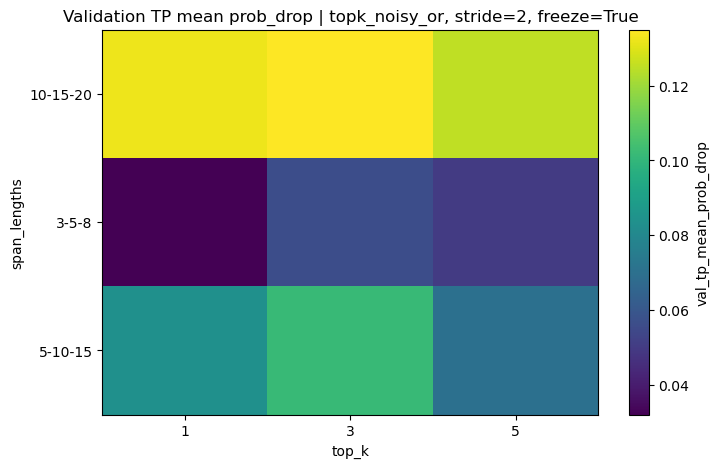

top_k,1,3,5
span_lengths_label,,,
10-15-20,0.132419,0.135032,0.124989
3-5-8,0.031947,0.056294,0.049984
5-10-15,0.083566,0.101466,0.070183


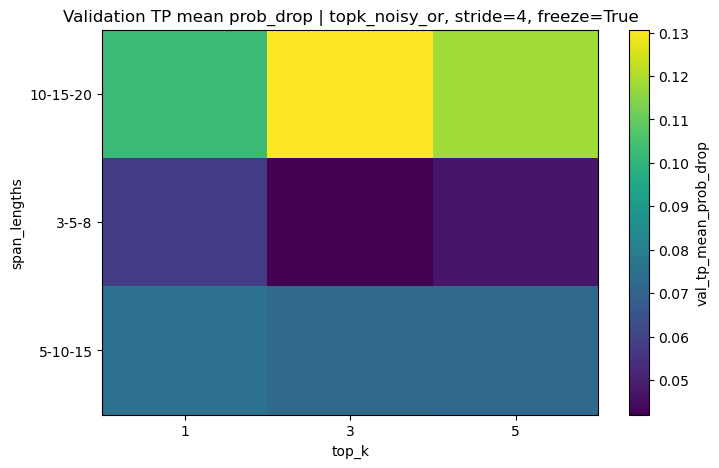

top_k,1,3,5
span_lengths_label,,,
10-15-20,0.102593,0.130676,0.118485
3-5-8,0.057901,0.042025,0.047337
5-10-15,0.074936,0.072575,0.072243


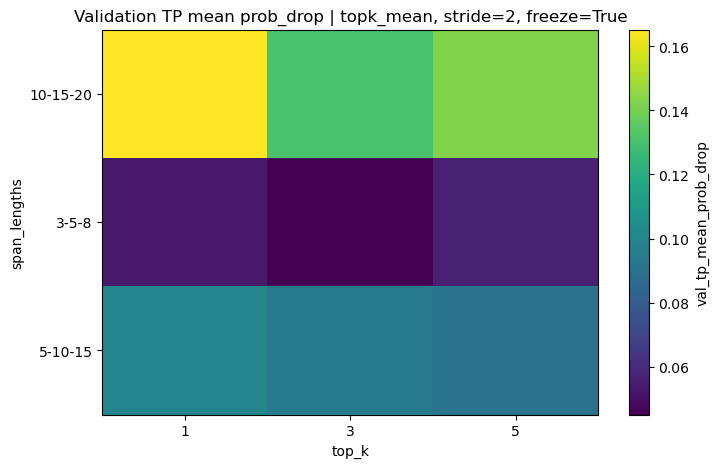

top_k,1,3,5
span_lengths_label,,,
10-15-20,0.165269,0.130617,0.142286
3-5-8,0.053784,0.045000,0.056212
5-10-15,0.099698,0.093397,0.091386


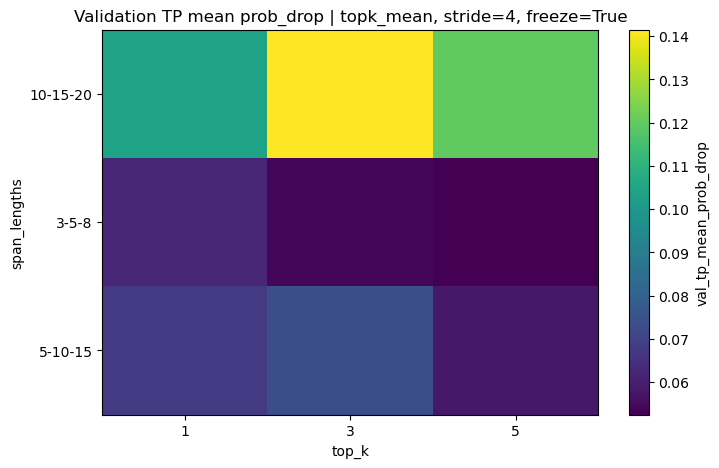

top_k,1,3,5
span_lengths_label,,,
10-15-20,0.103968,0.141514,0.119804
3-5-8,0.062027,0.053913,0.052467
5-10-15,0.067464,0.073830,0.058224


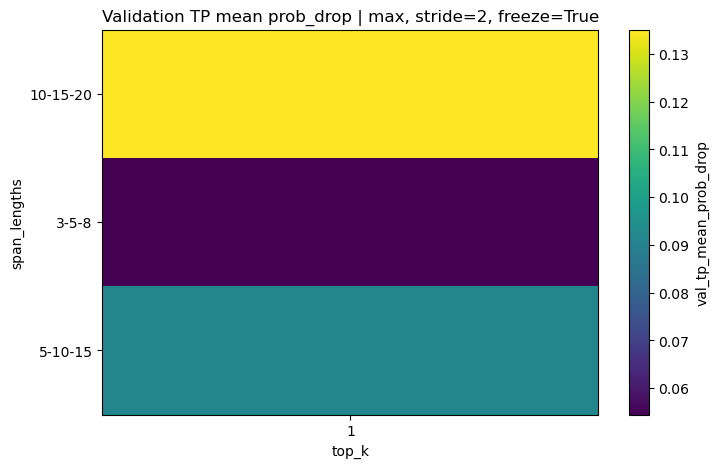

top_k,1
span_lengths_label,
10-15-20,0.135107
3-5-8,0.054474
5-10-15,0.091564


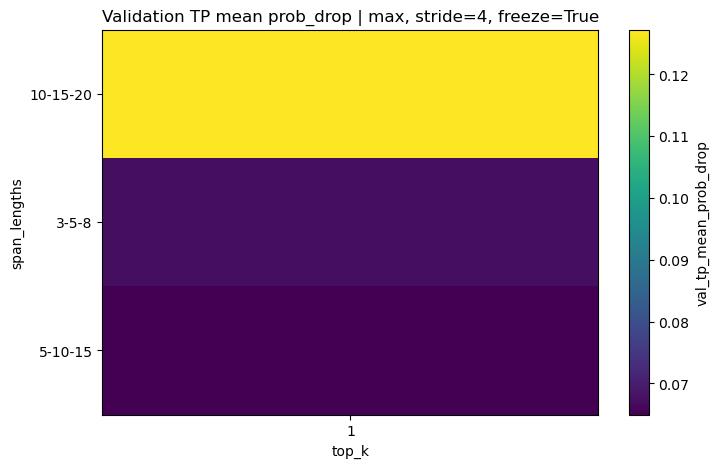

top_k,1
span_lengths_label,
10-15-20,0.127246
3-5-8,0.067271
5-10-15,0.064946


In [21]:
def plot_validation_heatmap(
    df,
    value_col,
    pooling_mode,
    stride,
    freeze_encoder,
    title,
    output_path,
):
    """Plot one validation heatmap for a fixed pooling/stride/freeze setting."""
    subset = df[
        (df["pooling_mode"] == pooling_mode) &
        (df["stride"] == stride) &
        (df["freeze_encoder"] == freeze_encoder)
    ].copy()
    
    if subset.empty:
        print("No data for", pooling_mode, stride, freeze_encoder)
        return
    
    heatmap_data = subset.pivot_table(
        index="span_lengths_label",
        columns="top_k",
        values=value_col,
        aggfunc="mean",
    )
    
    plt.figure(figsize=(8, 5))
    plt.imshow(heatmap_data, aspect="auto")
    plt.colorbar(label=value_col)
    
    plt.xticks(
        ticks=np.arange(len(heatmap_data.columns)),
        labels=heatmap_data.columns,
    )
    plt.yticks(
        ticks=np.arange(len(heatmap_data.index)),
        labels=heatmap_data.index,
    )
    
    plt.xlabel("top_k")
    plt.ylabel("span_lengths")
    plt.title(title)
    
    plt.savefig(output_path, dpi=300, bbox_inches="tight")
    plt.show()
    
    display(heatmap_data)


plot_dir = OUTPUT_DIR / "plots"
plot_dir.mkdir(parents=True, exist_ok=True)

for pooling_mode in POOLING_MODES:
    for stride in STRIDE_VALUES:
        for freeze_encoder in FREEZE_ENCODER_VALUES:
            plot_validation_heatmap(
                df=val_config_summary,
                value_col="val_tp_mean_prob_drop",
                pooling_mode=pooling_mode,
                stride=stride,
                freeze_encoder=freeze_encoder,
                title=(
                    f"Validation TP mean prob_drop | "
                    f"{pooling_mode}, stride={stride}, freeze={freeze_encoder}"
                ),
                output_path=plot_dir / (
                    f"heatmap_prob_drop_{pooling_mode}_stride{stride}_freeze{freeze_encoder}.png"
                ),
            )

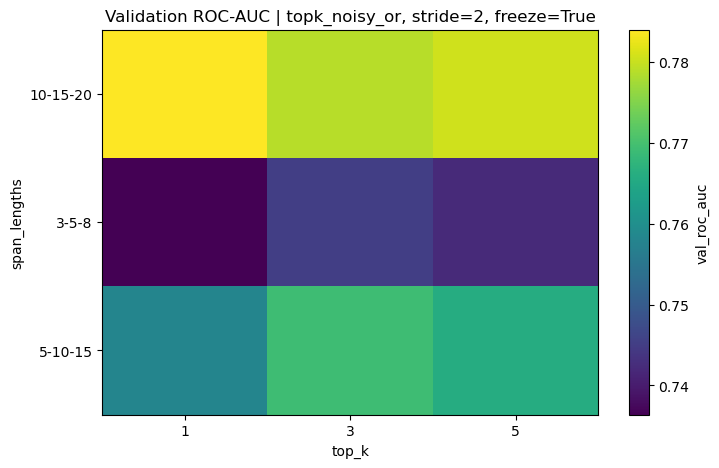

top_k,1,3,5
span_lengths_label,,,
10-15-20,0.784022,0.778898,0.780620
3-5-8,0.736391,0.745212,0.742019
5-10-15,0.758149,0.769153,0.765793


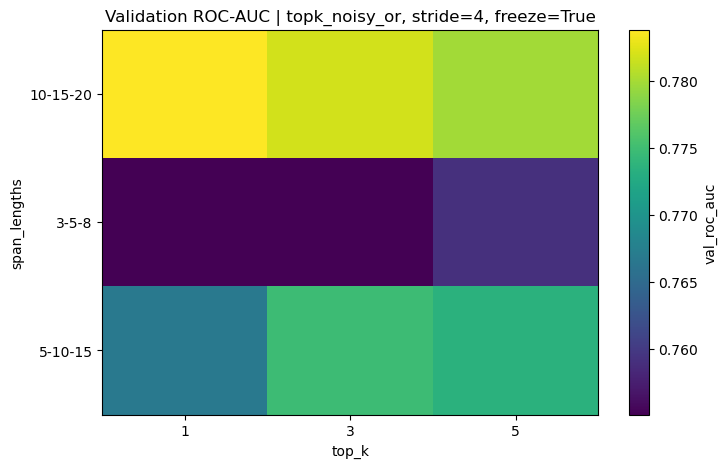

top_k,1,3,5
span_lengths_label,,,
10-15-20,0.783854,0.781922,0.779906
3-5-8,0.755124,0.755208,0.759073
5-10-15,0.766717,0.774782,0.773522


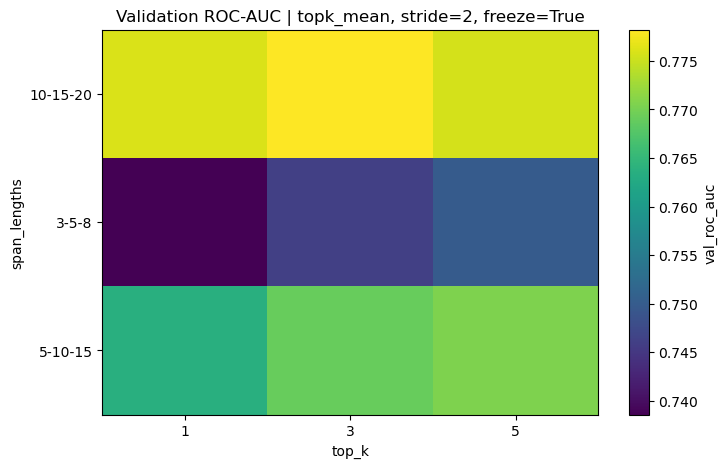

top_k,1,3,5
span_lengths_label,,,
10-15-20,0.776042,0.778226,0.775706
3-5-8,0.738575,0.746136,0.750000
5-10-15,0.763525,0.768943,0.770497


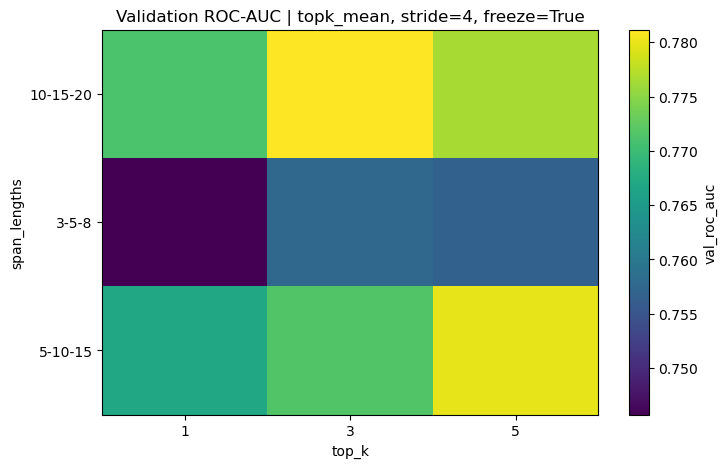

top_k,1,3,5
span_lengths_label,,,
10-15-20,0.771169,0.781166,0.776546
3-5-8,0.745716,0.757560,0.756720
5-10-15,0.766885,0.771589,0.779822


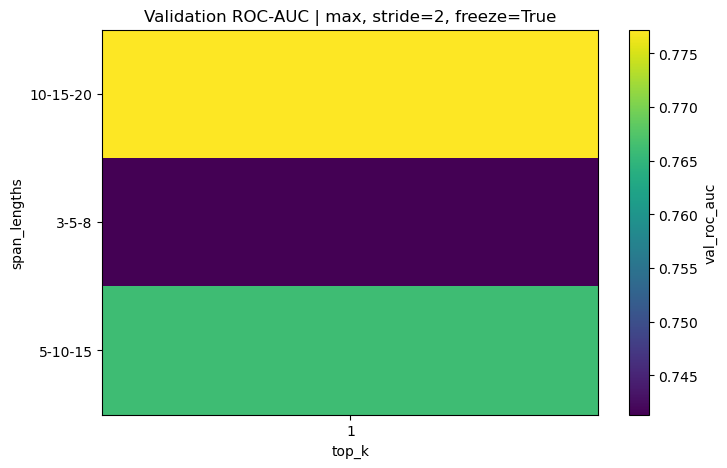

top_k,1
span_lengths_label,
10-15-20,0.777218
3-5-8,0.741347
5-10-15,0.766129


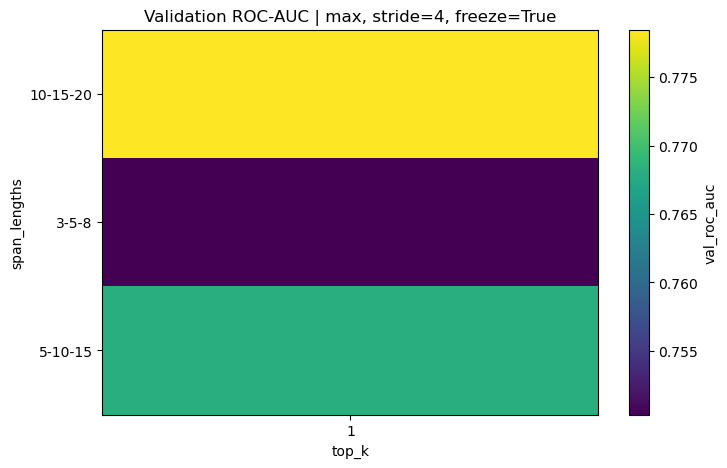

top_k,1
span_lengths_label,
10-15-20,0.778478
3-5-8,0.750336
5-10-15,0.768061


In [22]:
for pooling_mode in POOLING_MODES:
    for stride in STRIDE_VALUES:
        for freeze_encoder in FREEZE_ENCODER_VALUES:
            plot_validation_heatmap(
                df=val_config_summary,
                value_col="val_roc_auc",
                pooling_mode=pooling_mode,
                stride=stride,
                freeze_encoder=freeze_encoder,
                title=(
                    f"Validation ROC-AUC | "
                    f"{pooling_mode}, stride={stride}, freeze={freeze_encoder}"
                ),
                output_path=plot_dir / (
                    f"heatmap_auc_{pooling_mode}_stride{stride}_freeze{freeze_encoder}.png"
                ),
            )

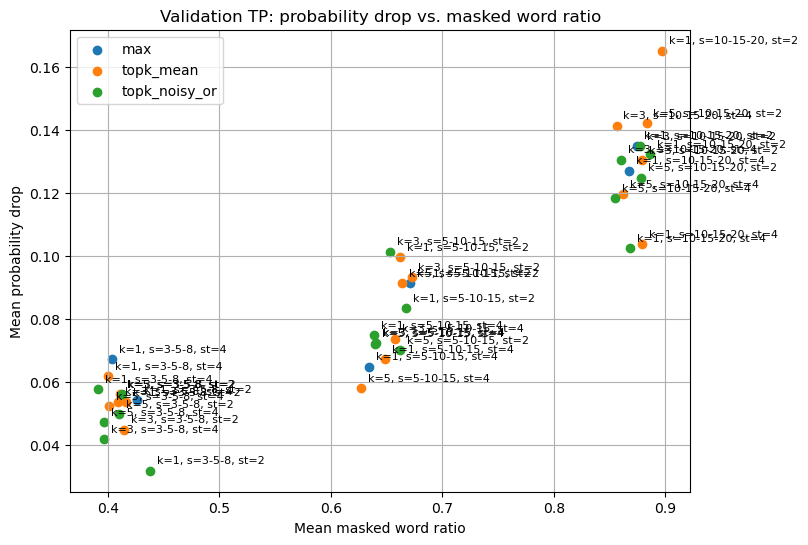

Saved plot: mil_results/mil_span_run_20260724_091019/plots/mil_validation_prob_drop_vs_masked_word_ratio.png


In [ ]:
plt.figure(figsize=(8, 6))

for pooling_mode in sorted(val_config_summary["pooling_mode"].unique()):
    subset = val_config_summary[
        val_config_summary["pooling_mode"] == pooling_mode
    ].copy()
    
    plt.scatter(
        subset["val_tp_mean_masked_token_ratio"],
        subset["val_tp_mean_prob_drop"],
        label=pooling_mode,
    )
    
    for _, row in subset.iterrows():
        plt.annotate(
            f"k={row['top_k']}, s={row['span_lengths_label']}, st={row['stride']}",
            (
                row["val_tp_mean_masked_token_ratio"],
                row["val_tp_mean_prob_drop"],
            ),
            textcoords="offset points",
            xytext=(5, 5),
            fontsize=8,
        )

plt.xlabel("Mean masked token ratio")
plt.ylabel("Mean probability drop")
plt.title("Validation TP: probability drop vs. masked token ratio")
plt.grid(True)
plt.legend()

plot_path = plot_dir / "mil_validation_prob_drop_vs_masked_token_ratio.png"
plt.savefig(plot_path, dpi=300, bbox_inches="tight")
plt.show()

print("Saved plot:", plot_path)

## Final selected MIL configuration

The final MIL configuration is selected on the validation split only.  
The test split is not used for hyperparameter selection.

The selected model is then applied to train, validation, and test to export comparable argument-level and span-level files.

In [24]:
BEST_CONFIG_ID = BEST_CONFIG["config_id"]

best_config_clean = {
    "pooling_mode": BEST_CONFIG["pooling_mode"],
    "top_k": int(BEST_CONFIG["top_k"]),
    "span_lengths": tuple(int(x) for x in str(BEST_CONFIG["span_lengths_label"]).split("-")),
    "span_lengths_label": BEST_CONFIG["span_lengths_label"],
    "stride": int(BEST_CONFIG["stride"]),
    "freeze_encoder": bool(BEST_CONFIG["freeze_encoder"]),
    "config_id": BEST_CONFIG_ID,
}

print(best_config_clean)

best_model = MILPoolingModel(
    model_name=MODEL_NAME,
    pooling_mode=best_config_clean["pooling_mode"],
    top_k=best_config_clean["top_k"],
    initial_instance_prob=INITIAL_INSTANCE_PROB,
    encoder_chunk_size=ENCODER_CHUNK_SIZE,
    encoder_dtype=ENCODER_DTYPE,
    freeze_encoder=best_config_clean["freeze_encoder"],
).to(TORCH_DEVICE)

best_model.load_state_dict(best_state_by_config[BEST_CONFIG_ID])
best_model.eval()

print("Loaded best validation model.")

{'pooling_mode': 'topk_noisy_or', 'top_k': 1, 'span_lengths': (3, 5, 8), 'span_lengths_label': '3-5-8', 'stride': 4, 'freeze_encoder': True, 'config_id': 'pool=topk_noisy_or__topk=1__spans=3-5-8__stride=4__freeze=True'}


Loaded best validation model.


In [25]:
def build_dataset_for_best_config(df):
    """Build a MIL dataset for the selected final config."""
    return AppropriatenessMILDataset(
        df,
        span_lengths=best_config_clean["span_lengths"],
        stride=best_config_clean["stride"],
    )


train_best_dataset = build_dataset_for_best_config(train_df)
val_best_dataset = build_dataset_for_best_config(val_df)
test_best_dataset = build_dataset_for_best_config(test_df)

train_argument_df, train_span_df = collect_mil_outputs(
    model=best_model,
    dataset=train_best_dataset,
    config=best_config_clean,
)

val_argument_df, val_span_df = collect_mil_outputs(
    model=best_model,
    dataset=val_best_dataset,
    config=best_config_clean,
)

test_argument_df, test_span_df = collect_mil_outputs(
    model=best_model,
    dataset=test_best_dataset,
    config=best_config_clean,
)

print(train_argument_df.shape, train_span_df.shape)
print(val_argument_df.shape, val_span_df.shape)
print(test_argument_df.shape, test_span_df.shape)

(1533, 26) (81057, 27)
(220, 26) (11908, 27)
(438, 26) (23531, 27)


In [26]:
train_argument_df, train_top_span_df = add_mil_perturbation_scores(
    train_argument_df,
    train_span_df,
    top_n_spans=MASKING_TOP_N_SPANS,
)

val_argument_df, val_top_span_df = add_mil_perturbation_scores(
    val_argument_df,
    val_span_df,
    top_n_spans=MASKING_TOP_N_SPANS,
)

test_argument_df, test_top_span_df = add_mil_perturbation_scores(
    test_argument_df,
    test_span_df,
    top_n_spans=MASKING_TOP_N_SPANS,
)

final_argument_df = pd.concat(
    [train_argument_df, val_argument_df, test_argument_df],
    ignore_index=True,
)

final_span_df = pd.concat(
    [train_span_df, val_span_df, test_span_df],
    ignore_index=True,
)

final_top_span_df = pd.concat(
    [train_top_span_df, val_top_span_df, test_top_span_df],
    ignore_index=True,
)

display(final_argument_df.head())
display(final_span_df.head())
display(final_top_span_df.head())

Classifier inference:   0%|          | 0/48 [00:00<?, ?it/s]

Classifier inference:   0%|          | 0/7 [00:00<?, ?it/s]

Classifier inference:   0%|          | 0/14 [00:00<?, ?it/s]

,global_row_id,post_id,split,issue,text,label,p_inappropriate_original,predicted_label_original,predicted_score_original,confusion_type,...,selected_span_texts,selected_span_char_start_indices,selected_span_char_end_indices,selected_span_word_start_indices,selected_span_word_end_indices,n_selected_spans,total_masked_chars,total_masked_words,n_words,masked_word_ratio
0,0,1,train,Is the school uniform a good or bad idea:,"people cant be forced to wear school uniforms,...",1,0.997032,LABEL_1,0.997032,TP,...,"[i mean each, i mean each person has, i mean e...","[47, 47, 47]","[58, 69, 84]","[8, 8, 8]","[10, 12, 15]",3,70,16,38,0.421053
1,1,2,train,Firefox vs internet explorer:,"That form of argument degrades this forum, and...",1,0.998218,LABEL_1,0.998218,TP,...,"[lowest common denominator. This word,, your s...","[87, 325, 87]","[124, 352, 145]","[16, 56, 16]","[20, 60, 23]",3,122,18,63,0.285714
2,2,3,train,If your spouse committed murder and he or she ...,I wouldnt turn her in becuase she is my wife. ...,0,0.030317,LABEL_0,0.969683,TN,...,"[a mistake that, by telling me what she did th...","[55, 108, 90]","[69, 141, 126]","[12, 24, 20]","[14, 31, 27]",3,83,19,37,0.513514
3,3,4,train,If your spouse committed murder and he or she ...,No I wouldn't turn in my spouse. Just because ...,1,0.998705,LABEL_1,0.998705,TP,...,"[in my spouse. Just because the girl that, bec...","[19, 38, 38]","[59, 61, 84]","[4, 8, 8]","[11, 12, 15]",3,109,21,25,0.840000
4,4,5,train,Tv is better than books:,TV is terrible. Except for Spongebob maybe. Th...,1,0.998405,LABEL_1,0.998405,TP,...,"[is awful. So, for Spongebob maybe. That's an,...","[102, 23, 102]","[114, 53, 123]","[16, 4, 16]","[18, 8, 20]",3,63,13,27,0.481481


,global_row_id,post_id,split,issue,label,confusion_type,mil_probability,mil_predicted_label,span_score,span_logit,...,candidate_span_length,text,pooling_mode,top_k,span_lengths,span_lengths_label,stride,freeze_encoder,config_id,span_rank
0,0,1,train,Is the school uniform a good or bad idea:,1,TP,0.287637,0,0.172668,-1.566835,...,3,"people cant be forced to wear school uniforms,...",topk_noisy_or,1,"(3, 5, 8)",3-5-8,4,True,pool=topk_noisy_or__topk=1__spans=3-5-8__strid...,4
1,0,1,train,Is the school uniform a good or bad idea:,1,TP,0.287637,0,0.036664,-3.268605,...,3,"people cant be forced to wear school uniforms,...",topk_noisy_or,1,"(3, 5, 8)",3-5-8,4,True,pool=topk_noisy_or__topk=1__spans=3-5-8__strid...,17
2,0,1,train,Is the school uniform a good or bad idea:,1,TP,0.287637,0,0.287637,-0.906889,...,3,"people cant be forced to wear school uniforms,...",topk_noisy_or,1,"(3, 5, 8)",3-5-8,4,True,pool=topk_noisy_or__topk=1__spans=3-5-8__strid...,1
3,0,1,train,Is the school uniform a good or bad idea:,1,TP,0.287637,0,0.070835,-2.573940,...,3,"people cant be forced to wear school uniforms,...",topk_noisy_or,1,"(3, 5, 8)",3-5-8,4,True,pool=topk_noisy_or__topk=1__spans=3-5-8__strid...,12
4,0,1,train,Is the school uniform a good or bad idea:,1,TP,0.287637,0,0.158719,-1.667791,...,3,"people cant be forced to wear school uniforms,...",topk_noisy_or,1,"(3, 5, 8)",3-5-8,4,True,pool=topk_noisy_or__topk=1__spans=3-5-8__strid...,5


,global_row_id,post_id,split,issue,label,confusion_type,mil_probability,mil_predicted_label,span_score,span_logit,...,candidate_span_length,text,pooling_mode,top_k,span_lengths,span_lengths_label,stride,freeze_encoder,config_id,span_rank
0,0,1,train,Is the school uniform a good or bad idea:,1,TP,0.287637,0,0.287637,-0.906889,...,3,"people cant be forced to wear school uniforms,...",topk_noisy_or,1,"(3, 5, 8)",3-5-8,4,True,pool=topk_noisy_or__topk=1__spans=3-5-8__strid...,1
1,0,1,train,Is the school uniform a good or bad idea:,1,TP,0.287637,0,0.277556,-0.956615,...,5,"people cant be forced to wear school uniforms,...",topk_noisy_or,1,"(3, 5, 8)",3-5-8,4,True,pool=topk_noisy_or__topk=1__spans=3-5-8__strid...,2
2,0,1,train,Is the school uniform a good or bad idea:,1,TP,0.287637,0,0.204352,-1.359314,...,8,"people cant be forced to wear school uniforms,...",topk_noisy_or,1,"(3, 5, 8)",3-5-8,4,True,pool=topk_noisy_or__topk=1__spans=3-5-8__strid...,3
3,1,2,train,Firefox vs internet explorer:,1,TP,0.742881,1,0.742881,1.060995,...,5,"That form of argument degrades this forum, and...",topk_noisy_or,1,"(3, 5, 8)",3-5-8,4,True,pool=topk_noisy_or__topk=1__spans=3-5-8__strid...,1
4,1,2,train,Firefox vs internet explorer:,1,TP,0.742881,1,0.707142,0.881544,...,5,"That form of argument degrades this forum, and...",topk_noisy_or,1,"(3, 5, 8)",3-5-8,4,True,pool=topk_noisy_or__topk=1__spans=3-5-8__strid...,2


In [ ]:
overall_summary = (
    final_argument_df
    .groupby([
        "split",
        "attribution_method",
        "pooling_mode",
        "top_k",
        "span_lengths_label",
        "stride",
        "freeze_encoder",
    ])
    .agg(
        n_arguments=("global_row_id", "nunique"),
        mean_prob_drop=("prob_drop", "mean"),
        median_prob_drop=("prob_drop", "median"),
        std_prob_drop=("prob_drop", "std"),
        positive_drop_rate=("prob_drop", lambda x: (x > 0).mean()),
        strong_drop_rate_001=("prob_drop", lambda x: (x > 0.01).mean()),
        strong_drop_rate_005=("prob_drop", lambda x: (x > 0.05).mean()),
        mean_p_original=("p_inappropriate_original", "mean"),
        mean_p_masked=("p_inappropriate_masked", "mean"),
        mean_mil_probability=("mil_probability", "mean"),
        std_mil_probability=("mil_probability", "std"),
        mean_n_selected_spans=("n_selected_spans", "mean"),
        mean_total_masked_words=("total_masked_words", "mean"),
        mean_total_masked_chars=("total_masked_chars", "mean"),
        mean_masked_token_ratio=("masked_token_ratio", "mean"),
    )
    .reset_index()
)

confusion_summary = (
    final_argument_df
    .groupby(["split", "confusion_type"])
    .agg(
        n_arguments=("global_row_id", "nunique"),
        mean_prob_drop=("prob_drop", "mean"),
        median_prob_drop=("prob_drop", "median"),
        std_prob_drop=("prob_drop", "std"),
        positive_drop_rate=("prob_drop", lambda x: (x > 0).mean()),
        mean_p_original=("p_inappropriate_original", "mean"),
        mean_p_masked=("p_inappropriate_masked", "mean"),
        mean_mil_probability=("mil_probability", "mean"),
        mean_total_masked_words=("total_masked_words", "mean"),
        mean_masked_token_ratio=("masked_token_ratio", "mean"),
    )
    .reset_index()
    .sort_values(["split", "confusion_type"])
)

test_summary = overall_summary[
    overall_summary["split"] == "test"
].copy()

display(overall_summary)
display(confusion_summary)
display(test_summary)

,split,attribution_method,pooling_mode,top_k,span_lengths_label,stride,freeze_encoder,n_arguments,mean_prob_drop,median_prob_drop,...,strong_drop_rate_001,strong_drop_rate_005,mean_p_original,mean_p_masked,mean_mil_probability,std_mil_probability,mean_n_selected_spans,mean_total_masked_words,mean_total_masked_chars,mean_masked_word_ratio
0,test,mil,topk_noisy_or,1,3-5-8,4,True,438,-0.026938,-0.000030,...,0.155251,0.089041,0.590804,0.617743,0.568380,0.328337,3.0,16.794521,90.210046,0.317451
1,train,mil,topk_noisy_or,1,3-5-8,4,True,1533,-0.028985,-0.000037,...,0.127202,0.077626,0.552141,0.581126,0.566399,0.330494,3.0,16.774299,90.198304,0.320883
2,validation,mil,topk_noisy_or,1,3-5-8,4,True,220,-0.016416,-0.000036,...,0.168182,0.095455,0.542075,0.558491,0.550530,0.322499,3.0,16.840909,89.895455,0.313380


,split,confusion_type,n_arguments,mean_prob_drop,median_prob_drop,std_prob_drop,positive_drop_rate,mean_p_original,mean_p_masked,mean_mil_probability,mean_total_masked_words,mean_masked_word_ratio
0,test,FN,39,-0.214622,-0.003340,0.408918,0.358974,0.049638,0.264259,0.499388,15.948718,0.243522
1,test,FP,71,0.034932,-0.000060,0.189023,0.464789,0.971585,0.936653,0.559754,17.070423,0.372598
2,test,TN,142,-0.093955,-0.000791,0.273552,0.415493,0.037216,0.131171,0.402778,16.119718,0.209885
3,test,TP,186,0.039961,0.000077,0.171886,0.564516,0.981555,0.941594,0.712567,17.381720,0.394021
4,train,FN,48,-0.142284,-0.002927,0.325495,0.458333,0.115297,0.257581,0.446231,16.312500,0.298083
5,train,FP,48,0.072743,-0.000077,0.322001,0.458333,0.915789,0.843046,0.373846,16.416667,0.369399
6,train,TN,652,-0.118933,-0.001420,0.280768,0.345092,0.030158,0.149091,0.391898,15.657975,0.239475
7,train,TP,785,0.046430,0.000122,0.184080,0.588535,0.990161,0.943731,0.730457,17.751592,0.386926
8,validation,FN,36,-0.096765,-0.001978,0.271070,0.333333,0.040581,0.137346,0.579732,16.305556,0.237453
9,validation,FP,30,0.010060,0.000310,0.160616,0.600000,0.968823,0.958762,0.443020,16.800000,0.353220


,split,attribution_method,pooling_mode,top_k,span_lengths_label,stride,freeze_encoder,n_arguments,mean_prob_drop,median_prob_drop,...,strong_drop_rate_001,strong_drop_rate_005,mean_p_original,mean_p_masked,mean_mil_probability,std_mil_probability,mean_n_selected_spans,mean_total_masked_words,mean_total_masked_chars,mean_masked_word_ratio
0,test,mil,topk_noisy_or,1,3-5-8,4,True,438,-0.026938,-0.00003,...,0.155251,0.089041,0.590804,0.617743,0.56838,0.328337,3.0,16.794521,90.210046,0.317451


In [28]:
final_output_dir = OUTPUT_DIR / "mil_results_final"
final_output_dir.mkdir(parents=True, exist_ok=True)

argument_csv_path = final_output_dir / (
    f"mil_final_all_splits"
    f"_{BEST_CONFIG_ID}"
    f"_argument_level.csv"
)

span_csv_path = final_output_dir / (
    f"mil_final_all_splits"
    f"_{BEST_CONFIG_ID}"
    f"_span_level.csv"
)

top_span_csv_path = final_output_dir / (
    f"mil_final_all_splits"
    f"_{BEST_CONFIG_ID}"
    f"_top_spans.csv"
)

overall_summary_csv_path = final_output_dir / (
    f"mil_final_all_splits"
    f"_{BEST_CONFIG_ID}"
    f"_overall_summary.csv"
)

confusion_summary_csv_path = final_output_dir / (
    f"mil_final_all_splits"
    f"_{BEST_CONFIG_ID}"
    f"_confusion_summary.csv"
)

test_summary_csv_path = final_output_dir / (
    f"mil_final_test"
    f"_{BEST_CONFIG_ID}"
    f"_summary.csv"
)

final_argument_df.to_csv(argument_csv_path, index=False, encoding="utf-8")
final_span_df.to_csv(span_csv_path, index=False, encoding="utf-8")
final_top_span_df.to_csv(top_span_csv_path, index=False, encoding="utf-8")
overall_summary.to_csv(overall_summary_csv_path, index=False, encoding="utf-8")
confusion_summary.to_csv(confusion_summary_csv_path, index=False, encoding="utf-8")
test_summary.to_csv(test_summary_csv_path, index=False, encoding="utf-8")

with open(final_output_dir / "best_config.json", "w", encoding="utf-8") as f:
    json.dump(best_config_clean, f, indent=2, ensure_ascii=False)

torch.save(
    {
        "model_state_dict": best_model.state_dict(),
        "best_config": best_config_clean,
        "validation_selection_row": BEST_CONFIG,
    },
    final_output_dir / "best_mil_model_checkpoint.pt",
)

print("Saved:")
print(argument_csv_path)
print(span_csv_path)
print(top_span_csv_path)
print(overall_summary_csv_path)
print(confusion_summary_csv_path)
print(test_summary_csv_path)

Saved:
mil_results/mil_span_run_20260724_091019/mil_results_final/mil_final_all_splits_pool=topk_noisy_or__topk=1__spans=3-5-8__stride=4__freeze=True_argument_level.csv
mil_results/mil_span_run_20260724_091019/mil_results_final/mil_final_all_splits_pool=topk_noisy_or__topk=1__spans=3-5-8__stride=4__freeze=True_span_level.csv
mil_results/mil_span_run_20260724_091019/mil_results_final/mil_final_all_splits_pool=topk_noisy_or__topk=1__spans=3-5-8__stride=4__freeze=True_top_spans.csv
mil_results/mil_span_run_20260724_091019/mil_results_final/mil_final_all_splits_pool=topk_noisy_or__topk=1__spans=3-5-8__stride=4__freeze=True_overall_summary.csv
mil_results/mil_span_run_20260724_091019/mil_results_final/mil_final_all_splits_pool=topk_noisy_or__topk=1__spans=3-5-8__stride=4__freeze=True_confusion_summary.csv
mil_results/mil_span_run_20260724_091019/mil_results_final/mil_final_test_pool=topk_noisy_or__topk=1__spans=3-5-8__stride=4__freeze=True_summary.csv


In [ ]:
def show_mil_example(result_df, index=0):
    """Display one MIL result with highlighted selected spans."""
    row = result_df.iloc[index]
    
    spans = json.loads(row["selected_spans_json"])
    marked = highlight_spans(row["text"], spans)
    
    display(HTML(f"""
    <div style="
        border:1px solid #ccc;
        border-radius:8px;
        padding:14px;
        margin:12px 0;
        font-family:Arial, sans-serif;
        line-height:1.45;
    ">
        <b>global_row_id:</b> {html.escape(str(row["global_row_id"]))}<br>
        <b>post_id:</b> {html.escape(str(row["post_id"]))}<br>
        <b>split:</b> {html.escape(str(row["split"]))}<br>
        <b>classifier confusion_type:</b> {html.escape(str(row["confusion_type"]))}<br>
        <b>MIL confusion_type:</b> {html.escape(str(row["mil_confusion_type"]))}<br>
        <b>issue:</b> {html.escape(str(row["issue"]))}<br>
        <b>pooling:</b> {html.escape(str(row["pooling_mode"]))} |
        <b>top_k:</b> {html.escape(str(row["top_k"]))} |
        <b>span_lengths:</b> {html.escape(str(row["span_lengths_label"]))} |
        <b>stride:</b> {html.escape(str(row["stride"]))} |
        <b>freeze_encoder:</b> {html.escape(str(row["freeze_encoder"]))}<br>
        <b>selected spans:</b> {html.escape(str(row["selected_span_texts"]))}<br>
        <b>p_original:</b> {float(row["p_inappropriate_original"]):.4f}<br>
        <b>p_masked:</b> {float(row["p_inappropriate_masked"]):.4f}<br>
        <b>prob_drop:</b> {float(row["prob_drop"]):.4f}<br>
        <b>MIL probability:</b> {float(row["mil_probability"]):.4f}<br>
        <b>masked_token_ratio:</b> {float(row["masked_token_ratio"]):.4f}<br>
        <hr>
        <p>{marked}</p>
    </div>
    """))

In [ ]:
test_valid = test_argument_df.copy()

best_examples = (
    test_valid
    .sort_values("prob_drop", ascending=False)
    .reset_index(drop=True)
)

print("Best MIL perturbation examples:")
display(
    best_examples[
        [
            "global_row_id",
            "post_id",
            "confusion_type",
            "mil_confusion_type",
            "prob_drop",
            "masked_token_ratio",
            "selected_span_texts",
        ]
    ].head(10)
)

for i in range(min(5, len(best_examples))):
    show_mil_example(best_examples, index=i)

Best MIL perturbation examples:


,global_row_id,post_id,confusion_type,mil_confusion_type,prob_drop,masked_word_ratio,selected_span_texts
0,2075,1609,TP,TP,0.990208,0.317460,"[should not mix. That solves the ""problem""., s..."
1,1935,887,FP,FP,0.969606,0.165138,[be heartbroken I'm sure!!!!!! Most of them co...
2,1851,475,TP,TP,0.965886,0.218391,"[Anyone who says Firefox 2 has major memory, W..."
3,1837,416,TP,FN,0.733613,0.211111,[police officer. These people will have you su...
4,2133,1902,TP,FN,0.708235,0.812500,"[if we don't start at, if we don't, How are we..."
5,1769,71,FP,FP,0.701037,0.266667,"[therefore the opposing, therefore the opposin..."
6,2159,2012,TP,TP,0.692678,0.281250,"[the hay is playing. And, not even close. owen..."
7,1813,291,TP,TP,0.673939,0.188235,"[If not, how can god love me or, should have l..."
8,1825,346,FP,TN,0.644856,1.230769,"[it isn't wrong it's genius, Everyone has sex,..."
9,2112,1775,TP,TP,0.644414,1.500000,"[weve believed in sky spirits for which no, ev..."


In [ ]:
worst_examples = (
    test_valid
    .sort_values("prob_drop", ascending=True)
    .reset_index(drop=True)
)

print("Lowest or negative MIL perturbation examples:")
display(
    worst_examples[
        [
            "global_row_id",
            "post_id",
            "confusion_type",
            "mil_confusion_type",
            "prob_drop",
            "masked_token_ratio",
            "selected_span_texts",
        ]
    ].head(10)
)

for i in range(min(5, len(worst_examples))):
    show_mil_example(worst_examples, index=i)

Lowest or negative MIL perturbation examples:


,global_row_id,post_id,confusion_type,mil_confusion_type,prob_drop,masked_word_ratio,selected_span_texts
0,2144,1939,FN,FN,-0.990240,0.615385,"[last up to, last up to 2 or, minute, but puni..."
1,1947,950,TN,TN,-0.988586,0.705882,"[If my wife was to commit murder and, told me ..."
2,1981,1107,FN,FN,-0.984604,0.184466,"[because we are not yet 100% sure if, like in ..."
3,2081,1621,TN,TN,-0.984371,0.375000,"[It's ok for, it's not often, parent to spank]"
4,1760,25,TN,TN,-0.977768,0.379310,"[250 Meg of, sieve. An opened session of, tabs..."
5,1829,387,FN,TP,-0.977195,0.205882,"[kids? As we are living in a developing, marri..."
6,1896,696,FN,TP,-0.976424,0.381818,"[them, same thing with girls, give them games,..."
7,1766,63,TN,TN,-0.976080,0.583333,"[with it, and also i, in because i don't think..."
8,2005,1217,TN,FP,-0.974984,0.169355,"[of good, right-suppoted ideas. Fox, me no bet..."
9,1865,528,FN,FN,-0.955980,0.314286,"[I believe that spanking you, I believe that, ..."


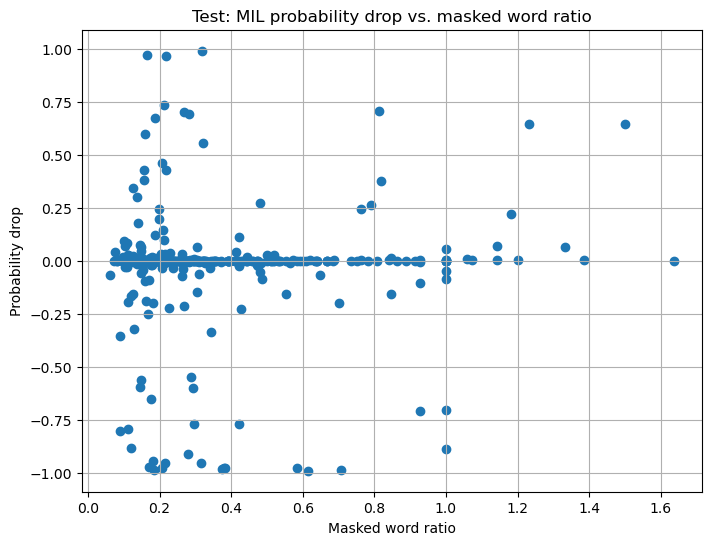

Saved plot: mil_results/mil_span_run_20260724_091019/plots/mil_test_prob_drop_vs_masked_word_ratio.png


In [ ]:
plt.figure(figsize=(8, 6))

plt.scatter(
    test_argument_df["masked_token_ratio"],
    test_argument_df["prob_drop"],
)

plt.xlabel("Masked token ratio")
plt.ylabel("Probability drop")
plt.title("Test: MIL probability drop vs. masked token ratio")
plt.grid(True)

plot_path = plot_dir / "mil_test_prob_drop_vs_masked_token_ratio.png"
plt.savefig(plot_path, dpi=300, bbox_inches="tight")
plt.show()

print("Saved plot:", plot_path)

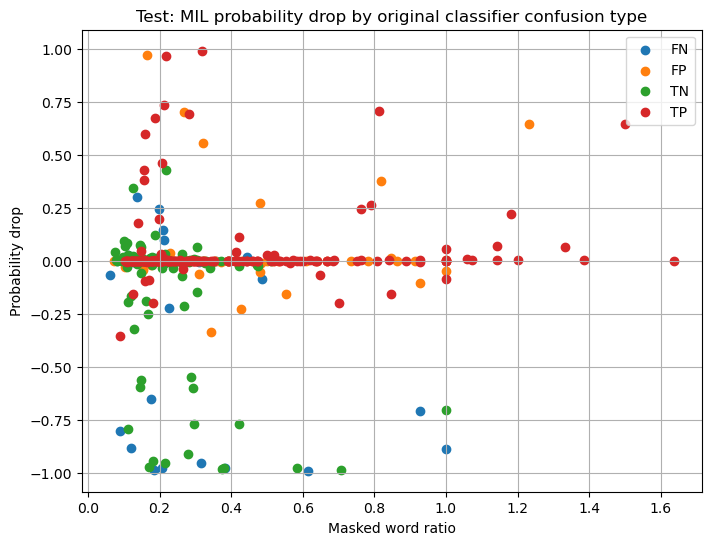

Saved plot: mil_results/mil_span_run_20260724_091019/plots/mil_test_prob_drop_by_confusion_type.png


In [ ]:
plt.figure(figsize=(8, 6))

for confusion_type in sorted(test_argument_df["confusion_type"].unique()):
    subset = test_argument_df[
        test_argument_df["confusion_type"] == confusion_type
    ]
    
    plt.scatter(
        subset["masked_token_ratio"],
        subset["prob_drop"],
        label=confusion_type,
    )

plt.xlabel("Masked token ratio")
plt.ylabel("Probability drop")
plt.title("Test: MIL probability drop by original classifier confusion type")
plt.grid(True)
plt.legend()

plot_path = plot_dir / "mil_test_prob_drop_by_confusion_type.png"
plt.savefig(plot_path, dpi=300, bbox_inches="tight")
plt.show()

print("Saved plot:", plot_path)

## Interpretation

The MIL bag-level metrics evaluate whether the trained MIL model can reproduce the document-level inappropriateness labels. They do not directly validate the correctness of the extracted spans because no gold span-level annotations are available.

The perturbation evaluation provides a proxy for span relevance. If masking the top-ranked MIL spans reduces the inappropriate probability of the original Ziegenbein classifier, this indicates that the selected spans capture information relevant to the document-level classifier.

Therefore, the final evaluation consists of two complementary parts:

1. **Bag-level classification quality**  
   Evaluates whether the MIL model learns a useful document-level decision function.

2. **Perturbation-based span evaluation**  
   Evaluates whether the selected MIL spans affect the original document-level classifier when removed or masked.